In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image 

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

In [2]:
LABELS_PATH = "../dataset/labels/labels.csv"

df = pd.read_csv(LABELS_PATH)

df.head()

,image,label
0,1.png,𑚀
1,2.png,𑚁
2,3.png,𑚂
3,4.png,𑚃
4,5.png,𑚄


In [3]:
print(df.shape)
print(df.head())

(229, 2)
   image label
0  1.png     𑚀
1  2.png     𑚁
2  3.png     𑚂
3  4.png     𑚃
4  5.png     𑚄


In [4]:
labels = sorted(df["label"].unique())

label_to_idx = {
    label: idx
    for idx, label in enumerate(labels)
}

idx_to_label = {
    idx: label
    for label, idx in label_to_idx.items()
}

NUM_CLASSES = len(labels)

print(NUM_CLASSES)

45


In [5]:
label_to_idx

{'𑚀': 0,
 '𑚀𑚫': 1,
 '𑚀𑚬': 2,
 '𑚁': 3,
 '𑚂': 4,
 '𑚃': 5,
 '𑚄': 6,
 '𑚅': 7,
 '𑚆': 8,
 '𑚇': 9,
 '𑚈': 10,
 '𑚉': 11,
 '𑚊': 12,
 '𑚋': 13,
 '𑚌': 14,
 '𑚍': 15,
 '𑚎': 16,
 '𑚏': 17,
 '𑚐': 18,
 '𑚑': 19,
 '𑚒': 20,
 '𑚓': 21,
 '𑚔': 22,
 '𑚕': 23,
 '𑚖': 24,
 '𑚗': 25,
 '𑚘': 26,
 '𑚙': 27,
 '𑚚': 28,
 '𑚛': 29,
 '𑚜': 30,
 '𑚝': 31,
 '𑚞': 32,
 '𑚟': 33,
 '𑚠': 34,
 '𑚡': 35,
 '𑚢': 36,
 '𑚣': 37,
 '𑚤': 38,
 '𑚥': 39,
 '𑚦': 40,
 '𑚧': 41,
 '𑚨': 42,
 '𑚩': 43,
 '𑚪': 44}

In [6]:
with open("label_to_idx.json", "w", encoding="utf-8") as f:
    json.dump(
        label_to_idx,
        f,
        ensure_ascii=False,
        indent=4,
    )

with open("idx_to_label.json", "w", encoding="utf-8") as f:
    json.dump(
        idx_to_label,
        f,
        ensure_ascii=False,
        indent=4,
    )

In [7]:
IMAGE_SIZE = 256

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),
    transforms.ToTensor(),
])

In [10]:
class TankriDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        transform=None
    ):

        self.dataframe = dataframe

        self.image_dir = image_dir

        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, idx):

        image_name = self.dataframe.iloc[idx]["image"]

        label = self.dataframe.iloc[idx]["label"]

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        image = Image.open(image_path)

        if self.transform:
            image = self.transform(image)

        label = label_to_idx[label]

        return image, label

c:\Users\atmar\anaconda3\envs\aimlenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 71296 (\N{TAKRI LETTER A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


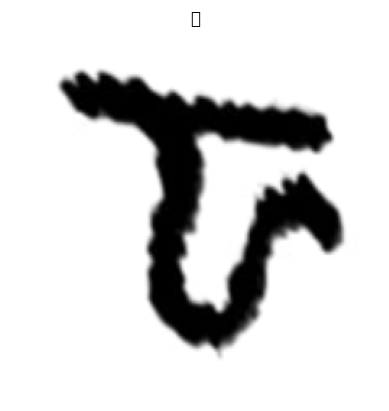

In [11]:
dataset = TankriDataset(
    dataframe=df,
    image_dir="../dataset/images",
    transform=transform
)
image, label = dataset[0]

plt.imshow(
    image.squeeze(),
    cmap="gray"
)

plt.title(idx_to_label[label])

plt.axis("off")

plt.show()

In [12]:
image, label = dataset[0]

print(type(image))
print(image.dtype)
print(image.shape)
print(label)
print(idx_to_label[label]) 
print(image.min())
print(image.max())

<class 'torch.Tensor'>
torch.float32
torch.Size([1, 256, 256])
0
𑚀
tensor(0.)
tensor(1.)


In [13]:
print(image[:, :5, :5])

tensor([[[1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.]]])


In [14]:
batch_size = 32

train_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

In [16]:
counts = df["label"].value_counts()

print(counts.sort_values())
print(counts[counts == 1])
print(counts[counts == 2])

label
𑚀𑚬    1
𑚪     1
𑚒     2
𑚓     2
𑚎     2
𑚂     3
𑚅     3
𑚣     3
𑚕     3
𑚌     4
𑚙     4
𑚡     4
𑚗     4
𑚨     5
𑚄     5
𑚔     5
𑚆     5
𑚍     5
𑚏     5
𑚇     5
𑚋     5
𑚜     5
𑚞     5
𑚠     5
𑚚     5
𑚐     5
𑚟     5
𑚩     6
𑚝     6
𑚛     6
𑚤     6
𑚖     6
𑚥     6
𑚑     6
𑚧     6
𑚘     6
𑚢     7
𑚊     7
𑚦     7
𑚉     8
𑚀𑚫    8
𑚃     8
𑚁     8
𑚈     8
𑚀     8
Name: count, dtype: int64
label
𑚪     1
𑚀𑚬    1
Name: count, dtype: int64
label
𑚓    2
𑚒    2
𑚎    2
Name: count, dtype: int64


In [17]:
counts = df["label"].value_counts()

# Keep only classes with at least 2 samples
valid_classes = counts[counts >= 2].index

df_filtered = df[df["label"].isin(valid_classes)].copy()

print("Original images :", len(df))
print("Filtered images :", len(df_filtered))

print("Original classes :", df["label"].nunique())
print("Filtered classes :", df_filtered["label"].nunique())

Original images : 229
Filtered images : 227
Original classes : 45
Filtered classes : 43


In [18]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df_filtered,
    test_size=0.2,
    random_state=42,
    stratify=df_filtered["label"],
)

print(len(train_df))
print(len(val_df))

181
46


In [19]:
print(train_df["label"].value_counts().sort_index())
print(val_df["label"].value_counts().sort_index())

label
𑚀     6
𑚀𑚫    6
𑚁     6
𑚂     2
𑚃     6
𑚄     4
𑚅     2
𑚆     4
𑚇     4
𑚈     6
𑚉     6
𑚊     6
𑚋     4
𑚌     3
𑚍     4
𑚎     2
𑚏     4
𑚐     4
𑚑     5
𑚒     2
𑚓     2
𑚔     4
𑚕     2
𑚖     5
𑚗     3
𑚘     5
𑚙     3
𑚚     4
𑚛     5
𑚜     4
𑚝     5
𑚞     4
𑚟     4
𑚠     4
𑚡     3
𑚢     6
𑚣     2
𑚤     5
𑚥     5
𑚦     6
𑚧     5
𑚨     4
𑚩     5
Name: count, dtype: int64
label
𑚀     2
𑚀𑚫    2
𑚁     2
𑚂     1
𑚃     2
𑚄     1
𑚅     1
𑚆     1
𑚇     1
𑚈     2
𑚉     2
𑚊     1
𑚋     1
𑚌     1
𑚍     1
𑚏     1
𑚐     1
𑚑     1
𑚔     1
𑚕     1
𑚖     1
𑚗     1
𑚘     1
𑚙     1
𑚚     1
𑚛     1
𑚜     1
𑚝     1
𑚞     1
𑚟     1
𑚠     1
𑚡     1
𑚢     1
𑚣     1
𑚤     1
𑚥     1
𑚦     1
𑚧     1
𑚨     1
𑚩     1
Name: count, dtype: int64


In [20]:
labels = sorted(df_filtered["label"].unique())

label_to_idx = {
    label: idx
    for idx, label in enumerate(labels)
}

idx_to_label = {
    idx: label
    for label, idx in label_to_idx.items()
}

NUM_CLASSES = len(labels)

print(NUM_CLASSES)

43


In [21]:
with open("label_to_idx.json", "w", encoding="utf-8") as f:
    json.dump(
        label_to_idx,
        f,
        ensure_ascii=False,
        indent=4,
    )

with open("idx_to_label.json", "w", encoding="utf-8") as f:
    json.dump(
        idx_to_label,
        f,
        ensure_ascii=False,
        indent=4,
    )

In [ ]:
class TankriCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),


            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),


            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )

        )

        self.classifier = nn.Sequential(
            
            nn.AdaptiveAvgPool2d((1, 1)),

            nn.Flatten(),

            nn.Linear(
                128,
                num_classes
            )

        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [24]:
model = TankriCNN(NUM_CLASSES)
print(model)

TankriCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=131072, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=43, bias=True)
  )
)


In [25]:
total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Trainable Parameters: {total_params:,}")

Total Trainable Parameters: 16,875,563


In [26]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

model = model.to(device)

cuda


In [27]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [36]:
train_dataset = TankriDataset(
    dataframe=train_df,
    image_dir="../dataset/images",
    transform=transform
)

val_dataset = TankriDataset(
    dataframe=val_df,
    image_dir="../dataset/images",
    transform=transform
)

In [37]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [38]:
EPOCHS = 20

# For plotting later
train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

for epoch in range(EPOCHS):

    # -------------------------
    # TRAINING
    # -------------------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        # Move batch to GPU/CPU
        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Compute gradients
        loss.backward()

        # Update weights
        optimizer.step()

        # -------------------------
        # Statistics
        # -------------------------

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # -------------------------
    # VALIDATION
    # -------------------------

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            val_correct += (predictions == labels).sum().item()

            val_total += labels.size(0)

    val_loss = val_running_loss / len(val_loader)
    val_acc = val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/20] | Train Loss: 5.0606 | Train Acc: 0.0110 | Val Loss: 3.7470 | Val Acc: 0.0435
Epoch [2/20] | Train Loss: 3.7700 | Train Acc: 0.0221 | Val Loss: 3.7229 | Val Acc: 0.0435
Epoch [3/20] | Train Loss: 3.7246 | Train Acc: 0.0276 | Val Loss: 3.7015 | Val Acc: 0.0435
Epoch [4/20] | Train Loss: 3.6752 | Train Acc: 0.0608 | Val Loss: 3.6825 | Val Acc: 0.0870
Epoch [5/20] | Train Loss: 3.5177 | Train Acc: 0.1160 | Val Loss: 3.5887 | Val Acc: 0.1739
Epoch [6/20] | Train Loss: 3.0373 | Train Acc: 0.2707 | Val Loss: 3.4141 | Val Acc: 0.1522
Epoch [7/20] | Train Loss: 2.3697 | Train Acc: 0.4199 | Val Loss: 3.3233 | Val Acc: 0.2174
Epoch [8/20] | Train Loss: 1.5355 | Train Acc: 0.6133 | Val Loss: 3.6668 | Val Acc: 0.2174
Epoch [9/20] | Train Loss: 0.8268 | Train Acc: 0.7680 | Val Loss: 3.7308 | Val Acc: 0.1739
Epoch [10/20] | Train Loss: 0.3619 | Train Acc: 0.9116 | Val Loss: 4.2364 | Val Acc: 0.2174
Epoch [11/20] | Train Loss: 0.1470 | Train Acc: 0.9558 | Val Loss: 5.0321 | Val Acc: 0.15